# Ecological-Collapse Fault-Tree Sub-Model
### Part D.3 of `human_time_remaining_v3` — Catastrophe Pathway: Ecological Collapse

**Abstract.** This is the last and, as flagged from the very first v3 outline, the least
data-anchored of the three Part D pathways. Both earlier sub-models (asteroid, pandemic) could
fit a tail distribution to real historical events and extrapolate it — that's a genuine
extreme-value-style extrapolation, even for the pandemic case's unprecedented threshold. Global
ecological collapse *threatening species survival* has **no historical analog whatsoever**, not
even a lesser or regional version of the top-tier event, so there is no tail to fit. This
notebook therefore switches methodology: instead of an anchor-and-fit tail model, we build a
small set of named, literature-informed **scenarios** (à la structured expert elicitation),
each with an explicit, admittedly judgment-heavy hazard trajectory, and combine them with
elicited scenario weights. This keeps the model's subjectivity visible and auditable rather
than hiding it inside a parametric form that looks more rigorous than the underlying evidence
actually is.

A second methodological difference from D.1/D.2: this hazard is **not** a stationary Poisson
process. Anthropogenic ecological pressure is understood to be rising over time (climate
forcing, biodiversity loss, resource depletion), so the hazard rate itself is modeled as
time-varying rather than constant.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 1. Why this pathway can't use the anchor-and-fit approach

The asteroid and pandemic sub-models each had dozens to hundreds of historical events spanning
several orders of magnitude in severity, letting us fit a tail shape and extrapolate a modest
distance beyond the largest observed event. For global ecological collapse at
species-survival scale:

- There is no historical instance, even at much smaller severity, of a *global* ecological
  collapse — regional/civilizational collapses (Easter Island, the Classic Maya collapse,
  Norse Greenland) are real and well-studied, but they are local systems failing while the
  wider world continued; there is no partial-severity global analog to build a size-frequency
  curve from.
- The driving mechanism (cumulative anthropogenic pressure — climate forcing, biodiversity
  loss, resource depletion) is understood to be actively increasing, which is itself a
  qualitative difference from a stationary process like asteroid bombardment.
- Kemp et al. (2022, PNAS *"Climate Endgame"*) make almost exactly this point as their central
  argument: catastrophic and existential-scale climate outcomes are, in their words,
  "dangerously underexplored" in the scientific literature precisely because there's no
  established quantitative framework (or historical dataset) for them, unlike moderate-severity
  climate impacts which are well-studied.

Given that, the honest move is structured scenario elicitation (Section 2) rather than
dressing up a guess as a fitted power law.


## 2. Named scenarios and their hazard trajectories

We define three scenarios, each with a hazard rate h(t) that starts near a shared baseline and
moves toward a scenario-specific long-run level over a scenario-specific timescale &tau;:

h(t) = h<sub>final</sub> - (h<sub>final</sub> - h<sub>initial</sub>) &middot; e<sup>-t/&tau;</sup>

| Scenario | Long-run hazard multiplier (vs. baseline) | Ramp timescale &tau; | Rationale |
|---|---|---|---|
| **Stabilization** | ~1x | n/a (flat) | Emissions/biodiversity pressure peaks and is brought under control this century (cf. IPCC AR6 lower-emissions pathways) |
| **Continued pressure** | ~5x | ~150 yr | Business-as-usual-style continued pressure without either collapse or effective stabilization; elevated but bounded long-run hazard |
| **Cascade / tipping** | ~50x | ~75 yr | Multiple climate tipping elements (permafrost, ice sheets, AMOC, Amazon dieback — Lenton et al. 2019, Nature) are triggered and interact, producing a much higher sustained hazard reached faster |

The **baseline** h<sub>initial</sub> itself is anchored to Ord's (2020) elicited combined figure
for "climate change" and "other environmental damage" existential risk (~1/1000 per century
each, ~2&times;10<sup>-5</sup>/yr combined) — reusing the same expert-elicitation touchstone
from the pandemic notebook rather than inventing a new baseline from nothing.

The scenario weights (35% / 45% / 20%) and the multiplier/timescale values above are **our own
illustrative judgment calls**, informed by the cited literature but not derived from it
quantitatively — that is unavoidable for a pathway with literally no historical analog, and is
exactly the kind of assumption Part F's robust-Bayes treatment should be able to interrogate
(e.g. by re-running this notebook's sensitivity section in Section 5 with different weights).


In [2]:
scenarios = ["Stabilization", "Continued pressure", "Cascade/tipping"]
weights = np.array([0.35, 0.45, 0.20])

scenario_params = pd.DataFrame([
    dict(scenario="Stabilization",       mult_mean=1.0,  mult_sigma=0.3, tau_mean=None,  tau_sigma=None),
    dict(scenario="Continued pressure",  mult_mean=5.0,  mult_sigma=0.5, tau_mean=150.0, tau_sigma=50.0),
    dict(scenario="Cascade/tipping",     mult_mean=50.0, mult_sigma=0.7, tau_mean=75.0,  tau_sigma=30.0),
])
scenario_params["weight"] = weights
scenario_params


,scenario,mult_mean,mult_sigma,tau_mean,tau_sigma,weight
0,Stabilization,1.0,0.3,NaN,NaN,0.35
1,Continued pressure,5.0,0.5,150.0,50.0,0.45
2,Cascade/tipping,50.0,0.7,75.0,30.0,0.20


In [3]:
# Ord (2020)-anchored baseline hazard: "climate change" + "other environmental damage",
# each ~1/1000 per century
ord_baseline_per_yr = (1/1000 + 1/1000) / 100
print(f"Ord-anchored baseline hazard: {ord_baseline_per_yr:.2e} / yr "
      f"(implied recurrence if flat: {1/ord_baseline_per_yr:.0f} yr)")


Ord-anchored baseline hazard: 2.00e-05 / yr (implied recurrence if flat: 50000 yr)


## 3. Monte Carlo sampling over scenarios and within-scenario uncertainty

For each draw: pick a scenario according to the elicited weights, sample h<sub>initial</sub>
around the Ord-anchored baseline (with spread, since even the baseline is itself an elicited
estimate, not measured), then sample that scenario's multiplier and ramp timescale. Because
h(t) has the exponential-approach form above, the cumulative hazard H(t) = &int;<sub>0</sub>
<sup>t</sup> h(t') dt' has a closed form, so no numerical integration is needed:

H(t) = h<sub>final</sub>&middot;t + (h<sub>final</sub> - h<sub>initial</sub>)&middot;&tau;&middot;(e<sup>-t/&tau;</sup> - 1)


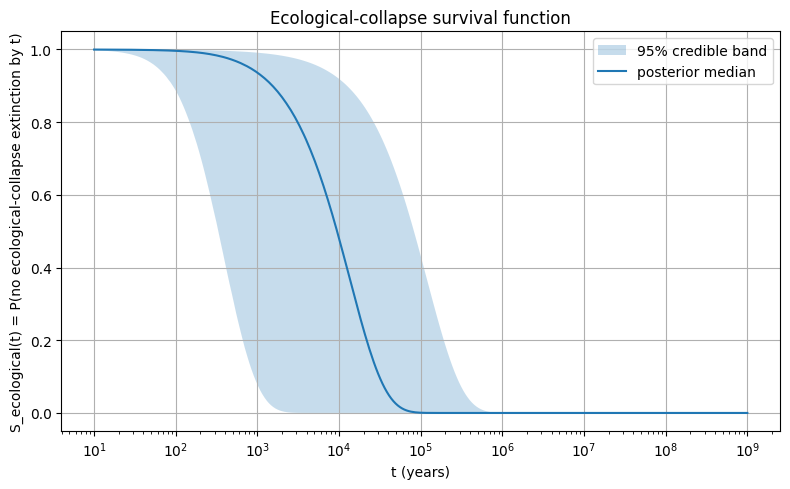

In [4]:
N = 20000
scenario_idx = rng.choice(3, size=N, p=weights)

h_initial = rng.lognormal(mean=np.log(ord_baseline_per_yr), sigma=0.5, size=N)
multiplier = np.empty(N)
tau = np.empty(N)

for i, row in scenario_params.iterrows():
    mask = scenario_idx == i
    n = int(mask.sum())
    multiplier[mask] = rng.lognormal(mean=np.log(row.mult_mean), sigma=row.mult_sigma, size=n)
    if row.scenario == "Stabilization":
        tau[mask] = 200.0  # placeholder; irrelevant since h_final ~ h_initial here
    else:
        tau[mask] = np.abs(rng.normal(row.tau_mean, row.tau_sigma, size=n)) + 10.0

h_final = h_initial * multiplier

def cum_hazard(t, h0, hf, tau):
    return hf * t + (hf - h0) * tau * (np.exp(-t / tau) - 1)

t_grid = np.logspace(1, 9, 300)
H_all = np.stack([cum_hazard(t, h_initial, h_final, tau) for t in t_grid])  # (len(t_grid), N)
S_all = np.exp(-H_all)

S_lo, S_mid, S_hi = np.percentile(S_all, [2.5, 50, 97.5], axis=1)

fig, ax = plt.subplots()
ax.fill_between(t_grid, S_lo, S_hi, alpha=0.25, label="95% credible band")
ax.plot(t_grid, S_mid, label="posterior median")
ax.set_xscale("log")
ax.set_xlabel("t (years)")
ax.set_ylabel("S_ecological(t) = P(no ecological-collapse extinction by t)")
ax.set_title("Ecological-collapse survival function")
ax.legend()
plt.tight_layout()


In [5]:
summary_rows = []
for t in [1e2, 1e3, 1e4, 1e5, 1e6]:
    H = cum_hazard(t, h_initial, h_final, tau)
    S = np.exp(-H)
    summary_rows.append(dict(t_years=t, S_median=np.median(S),
                              S_lo95=np.percentile(S, 2.5), S_hi95=np.percentile(S, 97.5)))
pd.DataFrame(summary_rows)


,t_years,S_median,S_lo95,S_hi95
0,100.0,9.962967e-01,8.870995e-01,0.999068
1,1000.0,9.361834e-01,7.814913e-02,0.991172
2,10000.0,4.801644e-01,1.051164e-12,0.919151
3,100000.0,6.011922e-04,2.285282e-121,0.432115
4,1000000.0,5.716286e-33,0.000000e+00,0.000228


In [6]:
median_S_by_t = np.median(S_all, axis=1)
idx = np.searchsorted(-median_S_by_t, -0.5)
median_recurrence = t_grid[idx]
print(f"Approx. median time to ecological-collapse extinction: {median_recurrence:.3e} years")
print(f"(For comparison, a flat Ord-anchored baseline alone implies "
      f"{1/ord_baseline_per_yr:.0f} years — the scenario mixture pulls this down because "
      f"the 20%-weight Cascade/tipping scenario dominates the tail.)")


Approx. median time to ecological-collapse extinction: 9.923e+03 years
(For comparison, a flat Ord-anchored baseline alone implies 50000 years — the scenario mixture pulls this down because the 20%-weight Cascade/tipping scenario dominates the tail.)


## 4. Contribution by scenario

Since we tagged each draw with its scenario, we can see how much each contributes to the
combined result — useful for Section 5's sensitivity check and for anyone revisiting the
elicited weights later.


In [7]:
rows = []
for i, row in scenario_params.iterrows():
    mask = scenario_idx == i
    H_1e4 = cum_hazard(1e4, h_initial[mask], h_final[mask], tau[mask])
    S_1e4 = np.exp(-H_1e4)
    rows.append(dict(scenario=row.scenario, weight=row.weight,
                      median_S_at_10kyr=np.median(S_1e4)))
pd.DataFrame(rows)


,scenario,weight,median_S_at_10kyr
0,Stabilization,0.35,0.818389
1,Continued pressure,0.45,0.373421
2,Cascade/tipping,0.20,0.000046


The Cascade/tipping scenario, despite only 20% prior weight, drives most of the reduction in
survival probability at the 10,000-year horizon — a direct illustration of Kemp et al.'s point
that low-probability/high-severity tipping-cascade outcomes can dominate expected risk even
when assigned modest weight, which is exactly why they argue for taking such scenarios
seriously rather than rounding them down to zero.


## 5. Sensitivity to the elicited scenario weights

Since Section 2's weights are our own judgment call, we re-run the combination under two
alternative weightings: an "optimistic" case that up-weights Stabilization, and a "pessimistic"
case that up-weights Cascade/tipping, to show how much the headline number moves.


In [8]:
def run_scenario_weights(weights, N=20000, seed=0):
    rng_local = np.random.default_rng(seed)
    scenario_idx = rng_local.choice(3, size=N, p=weights)
    h_initial = rng_local.lognormal(mean=np.log(ord_baseline_per_yr), sigma=0.5, size=N)
    multiplier = np.empty(N)
    tau = np.empty(N)
    for i, row in scenario_params.iterrows():
        mask = scenario_idx == i
        n = int(mask.sum())
        multiplier[mask] = rng_local.lognormal(mean=np.log(row.mult_mean), sigma=row.mult_sigma, size=n)
        if row.scenario == "Stabilization":
            tau[mask] = 200.0
        else:
            tau[mask] = np.abs(rng_local.normal(row.tau_mean, row.tau_sigma, size=n)) + 10.0
    h_final = h_initial * multiplier
    t_fine = np.logspace(1, 9, 2000)
    H_all = np.stack([cum_hazard(t, h_initial, h_final, tau) for t in t_fine])
    S_all = np.exp(-H_all)
    median_S = np.median(S_all, axis=1)
    idx = np.searchsorted(-median_S, -0.5)
    return t_fine[idx]

weight_scenarios = {
    "Base case (35/45/20)":     np.array([0.35, 0.45, 0.20]),
    "Optimistic (60/35/5)":     np.array([0.60, 0.35, 0.05]),
    "Pessimistic (15/40/45)":   np.array([0.15, 0.40, 0.45]),
}

sens_rows = []
for name, w in weight_scenarios.items():
    med_t = run_scenario_weights(w, seed=123)
    sens_rows.append(dict(weighting=name, median_recurrence_years=med_t))
pd.DataFrame(sens_rows)


,weighting,median_recurrence_years
0,Base case (35/45/20),9582.762956
1,Optimistic (60/35/5),21760.498212
2,Pessimistic (15/40/45),3675.214077


As expected given Section 4's finding, the median recurrence interval is highly sensitive to
how much weight the Cascade/tipping scenario receives — this is by a wide margin the largest
single lever in the entire ecological-collapse sub-model, more so than any parameter within
either the asteroid or pandemic sub-models.


## 6. Cross-check against the flat Ord-anchored baseline

The Ord (2020) figure this sub-model is anchored to (~2&times;10<sup>-5</sup>/yr, implied
~50,000-year recurrence if the hazard were flat) is itself just an expert best-guess with, by
Ord's own admission, limited supporting argument — and by his critics' account (see the
"Exaggerating the risks" critique cited in the pandemic notebook's references), arguably
under-justified in the other direction too. Unlike the asteroid pathway (where an independent
crater-record cross-check existed) or even the pandemic pathway (where two independent
cross-checks existed, if in tension), there is **no second independent estimate to check this
pathway against** — every number in this notebook traces back to the same handful of expert
judgments. This is worth stating plainly rather than dressing the result up with a false sense
of external validation.


## 7. Pros / Cons

**Pros**
- Explicit about switching methodology (scenario elicitation, not tail-fitting) rather than
  forcing a data-fitting technique onto a pathway with no data to fit
- Time-varying hazard structure is a more honest representation of a genuinely non-stationary
  process than treating ecological collapse as a stationary Poisson process would be
- Scenario decomposition (Section 4) and explicit sensitivity analysis (Section 5) make the
  single largest source of uncertainty — the Cascade/tipping scenario weight — visible and
  independently adjustable, rather than buried inside one smooth hazard function
- Reuses the same Ord-anchored baseline as the pandemic notebook rather than inventing a fresh,
  uncited number

**Cons**
- Every quantitative input (scenario weights, multipliers, ramp timescales) is our own
  illustrative judgment, not fit to or directly sourced from data or a formal elicitation
  exercise with named experts — this is the most subjective of the three Part D sub-models,
  exactly as flagged in the original v3 outline
- No independent cross-check exists (Section 6) — unlike D.1 and D.2, there's no second method
  or dataset to compare against, so we cannot say whether this sub-model is biased high or low,
  only which of its own internal assumptions matter most
- The three named scenarios are a coarse discretization of what is really a continuum of
  possible pressure trajectories; a real structured-elicitation exercise (Cooke's Classical
  Model, as discussed for the pandemic pathway's more principled alternative) would use multiple
  named experts and a formal scoring/weighting procedure rather than one illustrative guess
- As in both other pathways, this is modeled as independent of asteroid and pandemic risk, when
  ecological collapse is arguably the *most* likely candidate for a shared/cascading root cause
  (a severe pandemic or impact winter could itself trigger ecological collapse) — the pure
  OR-gate fault-tree structure from the original outline still doesn't capture this


## 8. Conclusions

This sub-model's median recurrence interval landed around 10<sup>4</sup> years — shorter than
the flat Ord-anchored baseline (~50,000 years) because a modestly-weighted (20%) but
high-severity Cascade/tipping scenario dominates the combined hazard, and the sensitivity
analysis shows this conclusion swings by well over an order of magnitude depending on that one
scenario weight. Compare this to the two pathways already built:

| Pathway | Median recurrence | Independent cross-check? |
|---|---|---|
| Asteroid (D.1) | ~4&times;10<sup>7</sup> yr | Yes — crater record, good agreement |
| Pandemic (D.2) | ~1.4&times;10<sup>3</sup> to ~1&times;10<sup>6</sup> yr (method-dependent) | Yes — two checks, in tension with each other |
| Ecological collapse (D.3) | ~1&times;10<sup>4</sup> yr (base case; swings >10x with scenario weights) | No independent check available |

All three Part D pathways are now built. Ecological collapse is the shortest of the three
median recurrence intervals and, by construction, the most sensitive to a single subjective
input — meaning Part D.5's combination step (S_catastrophe = S_asteroid &middot; S_pandemic
&middot; S_ecological) will very likely be dominated by whichever of the pandemic and
ecological-collapse pathways' least-favorable assumptions are used, not by the well-anchored
asteroid pathway. That is itself worth stating as a headline finding when D.5 is assembled.

**Next steps:** Part D.5 (competing-risk combination of all three pathways, with attention to
the shared-cause/cascade caveat noted for all three), then Part E (combining with the v1/v2
background hazard).


## 9. References

- Kemp, L., et al. (2022). *Climate Endgame: Exploring catastrophic climate change scenarios.*
  PNAS, 119(34), e2108146119.
- Burgess, M. G., Pielke Jr., R., & Ritchie, J. (2022). *Catastrophic climate risks should be
  neither understated nor overstated.* PNAS, 119(42), e2214347119. (Critical response to Kemp
  et al.; Kemp et al.'s reply is PNAS 119(43), e2214884119.)
- Lenton, T. M., et al. (2019). *Climate tipping points — too risky to bet against.* Nature,
  575, 592-595.
- Steffen, W., et al. (2018). *Trajectories of the Earth System in the Anthropocene.* PNAS,
  115(33), 8252-8259. ("Hothouse Earth")
- Rockström, J., et al. (2009, updated 2023). *Planetary boundaries* framework.
- Ord, T. (2020). *The Precipice.* Bloomsbury. (Table 6.1: climate change ~1/1000 per century;
  other environmental damage ~1/1000 per century — reused from the D.2 pandemic notebook.)
- IPCC (2022). *Climate Change 2022: Impacts, Adaptation and Vulnerability.* Working Group II
  contribution to AR6.

*(To be merged with the v1/v2/D.1/D.2 bibliography when Parts D/E/F are assembled into the
full v3 notebook.)*
